In [1]:
%pip install nibabel
%pip install numpy
%pip install matplotlib
%pip install tqdm
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\ronen\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Import Libraries

In [2]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
import pandas as pd

## Get Image Data

In [3]:
img_dir = "MRI_Seg_FBB10YC/"

In [4]:
img_paths = os.listdir(img_dir)

In [5]:
def pad_zeros(img: np.ndarray) -> np.ndarray:
    """
    Pad zeros to create 128 x 128 image.
    """
    first_dim, second_dim = img.shape

    col_pad = 128 - second_dim
    col_pad_side = col_pad // 2
    col_pad_left, col_pad_right = col_pad_side, col_pad_side
    if col_pad_side * 2 < col_pad:
        col_pad_right += 1
    img = np.concatenate(
        (
            np.zeros((first_dim, col_pad_left)),
            img,
            np.zeros((first_dim, col_pad_right))
        ), axis=1
    )

    row_pad = 128 - first_dim
    row_pad_side = row_pad // 2
    row_pad_top, row_pad_bottom = row_pad_side, row_pad_side
    if row_pad_side  * 2 < row_pad:
        row_pad_bottom += 1
    img = np.concatenate(
        (
            np.zeros((row_pad_top, 128)),
            img,
            np.zeros((row_pad_bottom, 128))
        )
    )

    return img

In [6]:
def get_Y() -> np.ndarray:
    """
    Concatenate 128 x 128 images side by side.
    """
    Y = None

    for i, img_path in enumerate(img_paths):
        img = nib.load(img_dir + img_path)
        img = img.get_fdata()
        img = np.mean(img, axis=2)  # 121 x 121 image.
        img = img[:, ~np.all(img == 0, axis=0)]  # Remove 0 columns.
        img = pad_zeros(img)
        if Y is not None:
            Y = np.concatenate((Y, img), axis=1)
        else:
            Y = img

    return Y

## Orthogonal Dictionary Learning

$\bm{Y}, \bm{X} \in \mathbb{R}^{n \times m}$, $\bm{A} \in O(n)$

Solve $\min_{\bm{q}} \frac{1}{m}\|\bm{q}^T\bm{Y}\|_1$ such that $\|\bm{q}\|_2 = 1$

$n \log(n)$ runs of subgradient method results with $\bm{A} = \{\bm{a}_1,\cdots,\bm{a}_n\}$

Solve $\min_{\bm{A}, \bm{X}} \frac{1}{2}\|\bm{Y} - \bm{A}\bm{X}\|_F^2 + \lambda \|\bm{X}\|_1$ such that $\bm{A} \in O(n)$

In [7]:
def SGM(Y: np.ndarray, niter: int=10000, eps: float=1e-5) -> tuple[np.ndarray, list[float]]:
    """
    Subgradient method.
    """
    objective_fun = lambda q: np.linalg.vector_norm(q.T @ Y, ord=1) /\
        Y.shape[1]
    projection = lambda q, z: z - q * (q.T @ z)
    gf = lambda q: Y @ np.sign(q.T @ Y).T / Y.shape[1]
    rgf = lambda q: projection(q, gf(q))
    rt = lambda z, u: (z + u) / np.linalg.vector_norm(z + u) 

    q = np.random.rand(Y.shape[0], 1)
    q /= np.linalg.vector_norm(q)
    out = np.empty(niter + 1)
    out[0] = objective_fun(q)
    for itr in range(niter):
        grad = rgf(q)
        eta = (itr + 1)**(-3 / 8) / (100 * np.sqrt(itr + 1))
        q = rt(q, -eta * grad)
        out[itr + 1] = objective_fun(q)
        if abs(out[itr + 1] - out[itr]) < eps:
            break
    return q, out[:itr + 2]

In [18]:
def ADM(Y: np.ndarray, A: np.ndarray, lam: float=0.02,
        niter: int=1000, eps: float=1e-5) -> tuple[np.ndarray, np.ndarray]:
    """
    Alternating Direction Method
    """
    objective_fun = lambda A, X:\
        0.5 * np.linalg.matrix_norm(Y - A @ X)**2 +\
            lam * np.linalg.matrix_norm(X, ord=1)

    out_prev = 1e4
    for itr in trange(niter):
        X = np.sign(A.T @ Y) * np.maximum(np.abs(A.T @ Y) - lam, 0)
        U, _, V = np.linalg.svd(Y @ X.T, full_matrices=False)
        A = U @ V
        out = objective_fun(A, X)
        if abs(out - out_prev) < eps:
            break
        out_prev = out
    return A, X

In [19]:
if not os.path.isdir("Plots"):
    os.mkdir("Plots")

 18%|█▊        | 177/1000 [00:04<00:21, 38.83it/s]


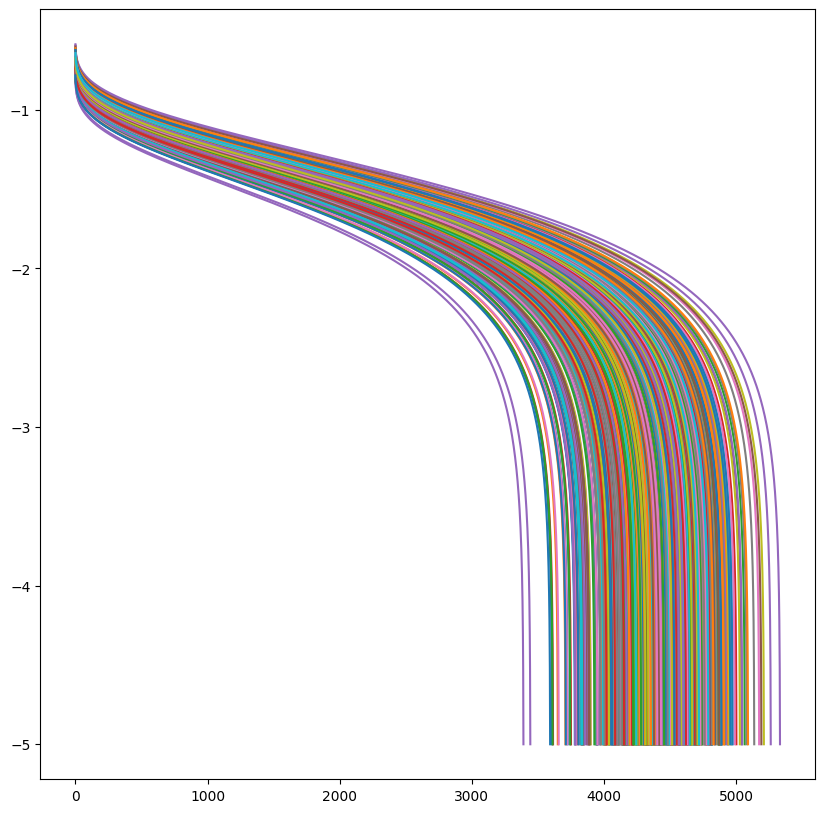

In [20]:
A = None
Y = get_Y()

num_iterations = round(Y.shape[0] * np.log(Y.shape[0]))
plt.subplots(figsize=(10, 10))
for i in trange(num_iterations):
    q_i, out_i = SGM(Y)
    if A is None:
        A = q_i
    else:
        A = np.concatenate((A, q_i), axis=1)
    plt.plot(
        range(len(out_i) - 1),
        np.log10(np.array(out_i[:-1] - out_i[-1]))
    )
plt.savefig(
    "Plots/subgradient_convergence.jpg",
    dpi=500, bbox_inches="tight"
)

for i in trange(num_iterations - Y.shape[0]):
    corr = np.corrcoef(A, rowvar=False)
    col = np.unravel_index(np.argmax(np.triu(corr, 1)), corr.shape)[1]
    A = np.delete(A, col, axis=1)

A_1, X_1 = ADM(Y, A, 0.01)
A_2, X_2 = ADM(Y, A, 0.02)
A_3, X_3 = ADM(Y, A, 0.05)
A_4, X_4 = ADM(Y, A, 0.10)

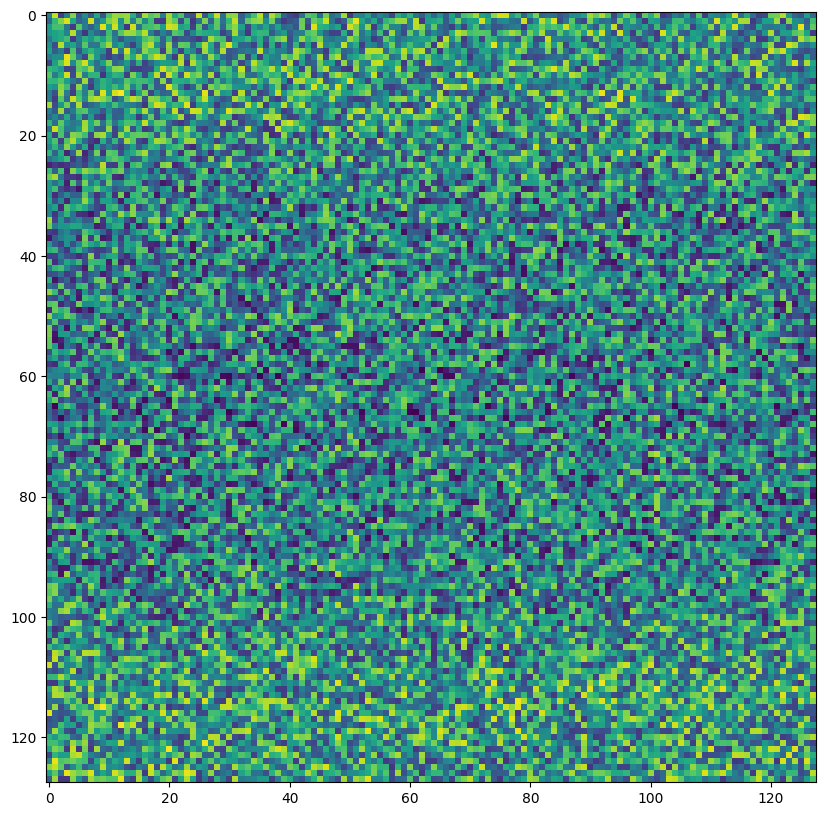

In [22]:
plt.subplots(figsize=(10, 10))
plt.imshow(A)
plt.savefig("Plots/original_A.jpg", dpi=500, bbox_inches="tight")
plt.show()

In [23]:
def calculate_sparsity(X_i: np.ndarray) -> tuple[float, int]:
    zeros = 128**2 - np.count_nonzero(X_i)

    # Remove 0 columns.
    zero_cols = np.all(X_i == 0, axis=0)
    X_i = X_i[:, ~zero_cols]

    sparsity = 0
    for i in range(X_i.shape[1]):
        col_vector = X_i[:, [[i]]]
        l1 = np.linalg.vector_norm(col_vector, ord=1)
        l2 = np.linalg.vector_norm(col_vector, ord=2)
        sparsity += (l1 / l2)
    sparsity /= X_i.shape[1]

    return sparsity, zeros

In [24]:
def plot_mri(Y: np.ndarray, A: list[np.ndarray], X: list[np.ndarray],
             lam: list[float], i: int) ->\
        tuple[str, list[int], int, list[float], list[float]]:
    Y_i = Y[:, i * 128:(i + 1) * 128]

    zeros_X_list = []
    zeros_Y = 128**2 - np.count_nonzero(Y_i)
    sparsity_list = []
    error_list = []

    _, ax = plt.subplots(1, 1 + len(A), figsize=(20, 20))
    ax[0].imshow(Y_i.T)
    ax[0].set_title("Original")

    print("Image:", img_paths[i])
    for j, (A_ij, X_ij, lam_j) in enumerate(zip(A, X, lam)):
        X_i = X_ij[:, i * 128:(i + 1) * 128]
        Y_tilde_i = A_ij @ X_i

        error = np.linalg.matrix_norm(Y_i - Y_tilde_i, ord=1) / (128**2)
        sparsity, zeros_X = calculate_sparsity(X_i)
        
        zeros_X_list.append(zeros_X)
        sparsity_list.append(sparsity)
        error_list.append(error)
        
        print()
        print("Lambda:", lam_j)
        print("Number of Zeros X:", zeros_X)
        print("Number of Zeros Y:", zeros_Y)
        print("Sparsity of X:", sparsity)
        print("Error of AX:", error)

        ax[j + 1].imshow(Y_tilde_i.T)
        ax[j + 1].set_title("Reconstructed lam=" + str(lam_j))
    
    plt.savefig(
        "Plots/" + img_paths[i].rstrip(".nii") + "_original_reconstructed.jpg",
        dpi=500, bbox_inches="tight"
    )
    plt.show()

    return img_paths[i], zeros_X_list, zeros_Y, sparsity_list, error_list

In [25]:
if not os.path.isdir("Tables"):
    os.mkdir("Tables")

Image: mwc1MR_1001_2_20160701130924.nii

Lambda: 0.01
Number of Zeros X: 12408
Number of Zeros Y: 7295
Sparsity of X: 1.8797875318188542
Error of AX: 3.689853638506378e-05

Lambda: 0.02
Number of Zeros X: 13941
Number of Zeros Y: 7295
Sparsity of X: 1.695697231810064
Error of AX: 6.361008183377101e-05

Lambda: 0.05
Number of Zeros X: 15391
Number of Zeros Y: 7295
Sparsity of X: 1.4785505854501027
Error of AX: 0.00011488012315867672

Lambda: 0.1
Number of Zeros X: 15907
Number of Zeros Y: 7295
Sparsity of X: 1.3326876804605516
Error of AX: 0.0001671476377001551


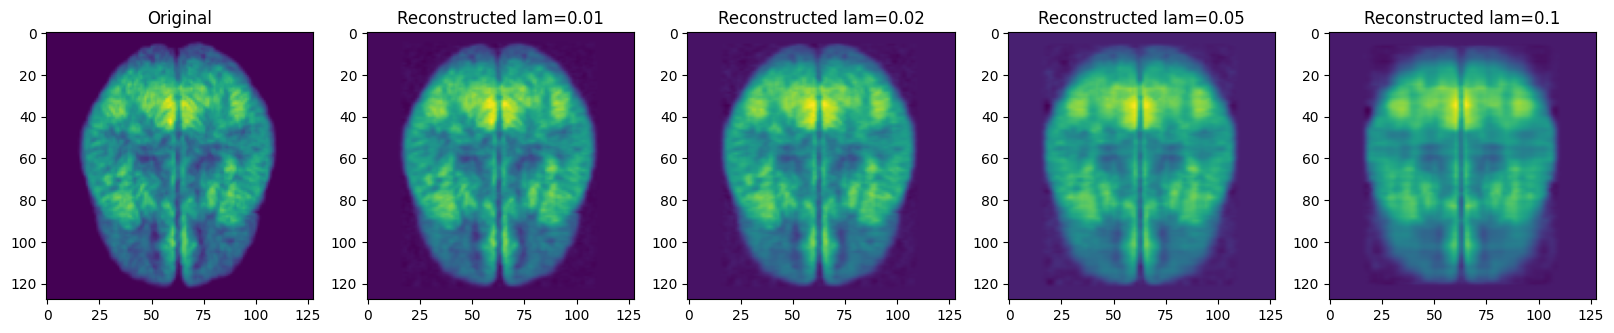

Image: mwc1MR_1002_2_20160715122634.nii

Lambda: 0.01
Number of Zeros X: 12614
Number of Zeros Y: 7223
Sparsity of X: 1.8758186867478293
Error of AX: 3.6300142064518333e-05

Lambda: 0.02
Number of Zeros X: 14068
Number of Zeros Y: 7223
Sparsity of X: 1.6725188512331282
Error of AX: 6.333142055850456e-05

Lambda: 0.05
Number of Zeros X: 15516
Number of Zeros Y: 7223
Sparsity of X: 1.457843284474741
Error of AX: 0.00011449863462907371

Lambda: 0.1
Number of Zeros X: 15931
Number of Zeros Y: 7223
Sparsity of X: 1.3220981898085336
Error of AX: 0.00016661036285763294


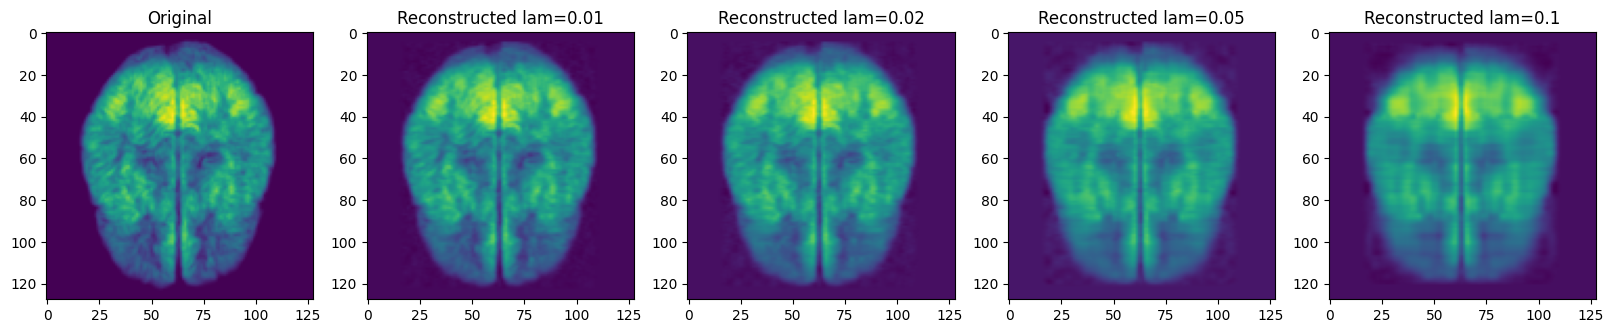

Image: mwc1MR_1003_5_20160914100618.nii

Lambda: 0.01
Number of Zeros X: 12240
Number of Zeros Y: 7225
Sparsity of X: 1.9043299501300301
Error of AX: 3.6576891492007464e-05

Lambda: 0.02
Number of Zeros X: 13894
Number of Zeros Y: 7225
Sparsity of X: 1.7159394671671588
Error of AX: 6.408075243967386e-05

Lambda: 0.05
Number of Zeros X: 15422
Number of Zeros Y: 7225
Sparsity of X: 1.47592712332704
Error of AX: 0.00011882916917124666

Lambda: 0.1
Number of Zeros X: 15896
Number of Zeros Y: 7225
Sparsity of X: 1.340617730856923
Error of AX: 0.00017568702865090988


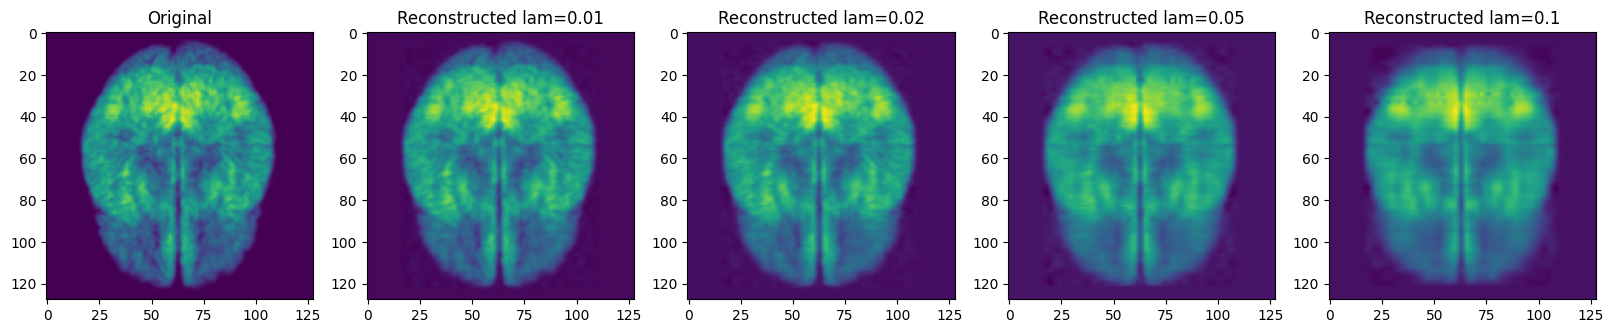

Image: mwc1MR_1004_2_20160805130611.nii

Lambda: 0.01
Number of Zeros X: 12585
Number of Zeros Y: 7342
Sparsity of X: 1.9022654072406315
Error of AX: 3.594751755274394e-05

Lambda: 0.02
Number of Zeros X: 14057
Number of Zeros Y: 7342
Sparsity of X: 1.7034520225762968
Error of AX: 6.114083331499017e-05

Lambda: 0.05
Number of Zeros X: 15518
Number of Zeros Y: 7342
Sparsity of X: 1.4628503345282349
Error of AX: 0.00010574937527205802

Lambda: 0.1
Number of Zeros X: 15939
Number of Zeros Y: 7342
Sparsity of X: 1.3158605763020004
Error of AX: 0.00015317765776385025


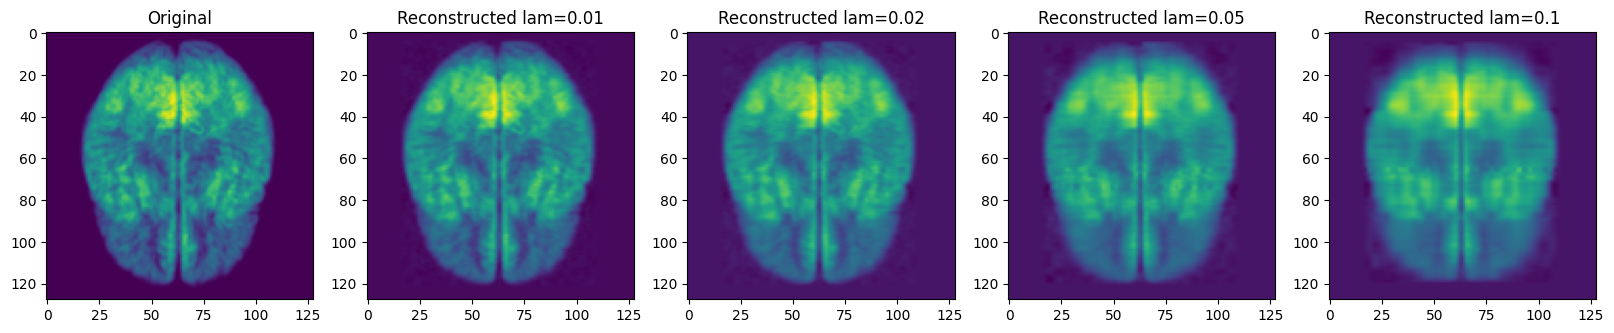

Image: mwc1MR_1005_2_20160722123224.nii

Lambda: 0.01
Number of Zeros X: 12308
Number of Zeros Y: 7143
Sparsity of X: 1.9430066131493728
Error of AX: 3.6808708282160106e-05

Lambda: 0.02
Number of Zeros X: 13822
Number of Zeros Y: 7143
Sparsity of X: 1.7485449585004198
Error of AX: 6.385984521772801e-05

Lambda: 0.05
Number of Zeros X: 15326
Number of Zeros Y: 7143
Sparsity of X: 1.5118423279075979
Error of AX: 0.00011920808425762731

Lambda: 0.1
Number of Zeros X: 15886
Number of Zeros Y: 7143
Sparsity of X: 1.3528218541445747
Error of AX: 0.00017058606147614175


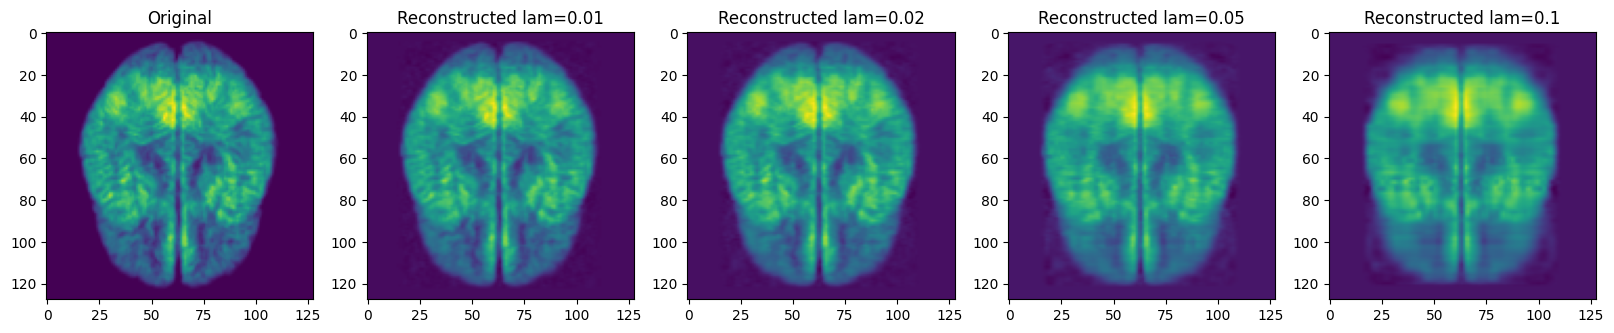

Image: mwc1MR_1007_2_20160719124145.nii

Lambda: 0.01
Number of Zeros X: 12732
Number of Zeros Y: 7191
Sparsity of X: 1.862316978740385
Error of AX: 3.5898007441988155e-05

Lambda: 0.02
Number of Zeros X: 14151
Number of Zeros Y: 7191
Sparsity of X: 1.6643602974298217
Error of AX: 6.0392046566485484e-05

Lambda: 0.05
Number of Zeros X: 15521
Number of Zeros Y: 7191
Sparsity of X: 1.4497264783285153
Error of AX: 0.00010758700168724298

Lambda: 0.1
Number of Zeros X: 15956
Number of Zeros Y: 7191
Sparsity of X: 1.3123642794972001
Error of AX: 0.0001729426402073576


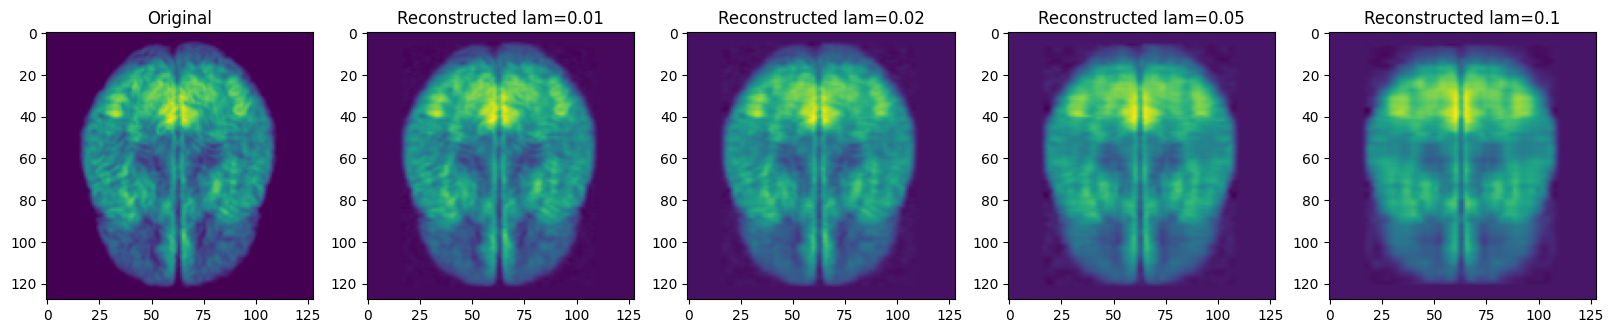

Image: mwc1MR_1011_2_20160823124322.nii

Lambda: 0.01
Number of Zeros X: 12374
Number of Zeros Y: 7070
Sparsity of X: 1.8535763125295135
Error of AX: 3.725300685136914e-05

Lambda: 0.02
Number of Zeros X: 13898
Number of Zeros Y: 7070
Sparsity of X: 1.6881698807010912
Error of AX: 6.21721972228697e-05

Lambda: 0.05
Number of Zeros X: 15386
Number of Zeros Y: 7070
Sparsity of X: 1.4804510847017691
Error of AX: 0.00011800084795464314

Lambda: 0.1
Number of Zeros X: 15881
Number of Zeros Y: 7070
Sparsity of X: 1.3483220030261098
Error of AX: 0.00018856063316926943


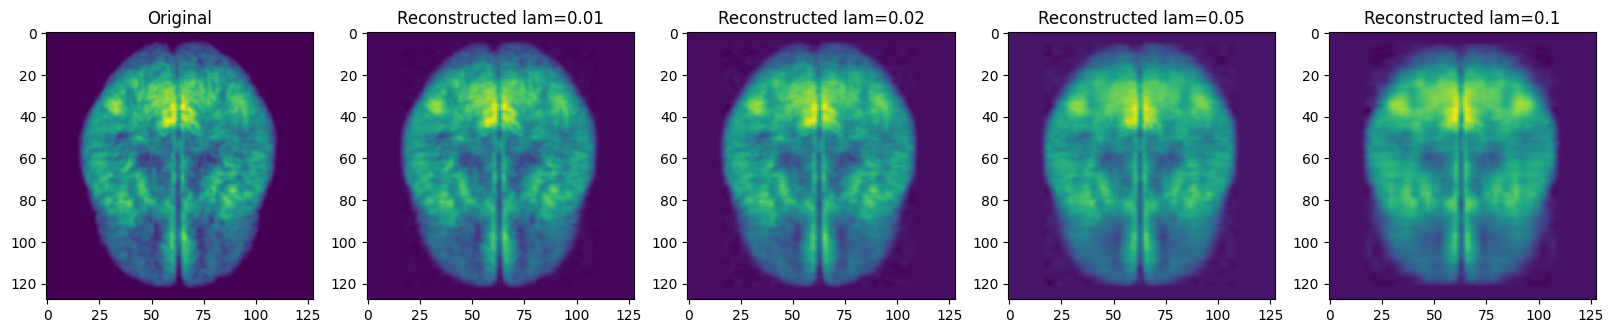

Image: mwc1MR_1012_2_20160722115010.nii

Lambda: 0.01
Number of Zeros X: 12399
Number of Zeros Y: 7333
Sparsity of X: 1.9209893955365684
Error of AX: 3.752135183720357e-05

Lambda: 0.02
Number of Zeros X: 13867
Number of Zeros Y: 7333
Sparsity of X: 1.7363619865456348
Error of AX: 6.244080240809851e-05

Lambda: 0.05
Number of Zeros X: 15360
Number of Zeros Y: 7333
Sparsity of X: 1.5045155487459505
Error of AX: 0.00012019494751742663

Lambda: 0.1
Number of Zeros X: 15881
Number of Zeros Y: 7333
Sparsity of X: 1.3590045995911382
Error of AX: 0.00017181740883446913


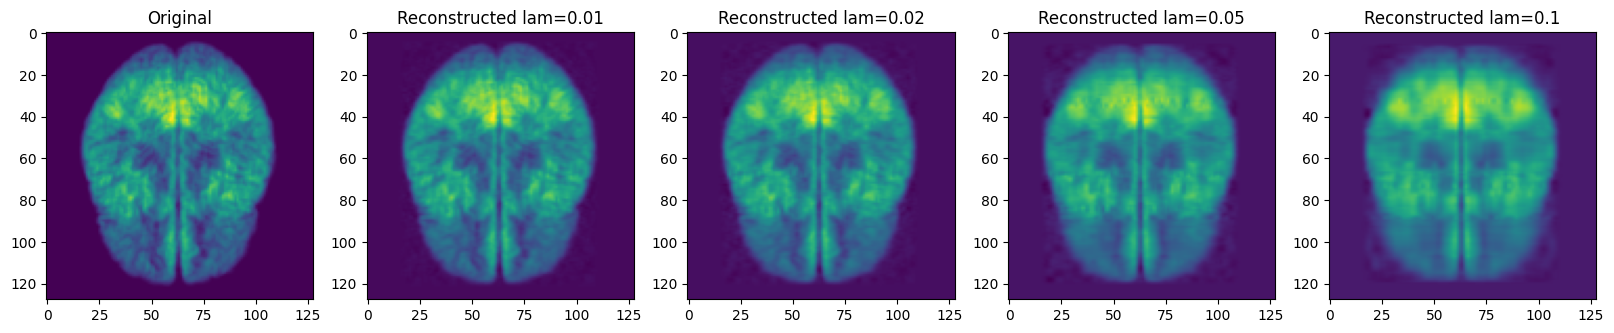

Image: mwc1MR_1017_2_20160902140329.nii

Lambda: 0.01
Number of Zeros X: 12338
Number of Zeros Y: 7275
Sparsity of X: 1.9236578486896685
Error of AX: 3.7480619483421056e-05

Lambda: 0.02
Number of Zeros X: 13899
Number of Zeros Y: 7275
Sparsity of X: 1.7375460719034492
Error of AX: 6.528714743899537e-05

Lambda: 0.05
Number of Zeros X: 15350
Number of Zeros Y: 7275
Sparsity of X: 1.5178842786814708
Error of AX: 0.00011596832152810863

Lambda: 0.1
Number of Zeros X: 15872
Number of Zeros Y: 7275
Sparsity of X: 1.3658177854814708
Error of AX: 0.00018412657892973386


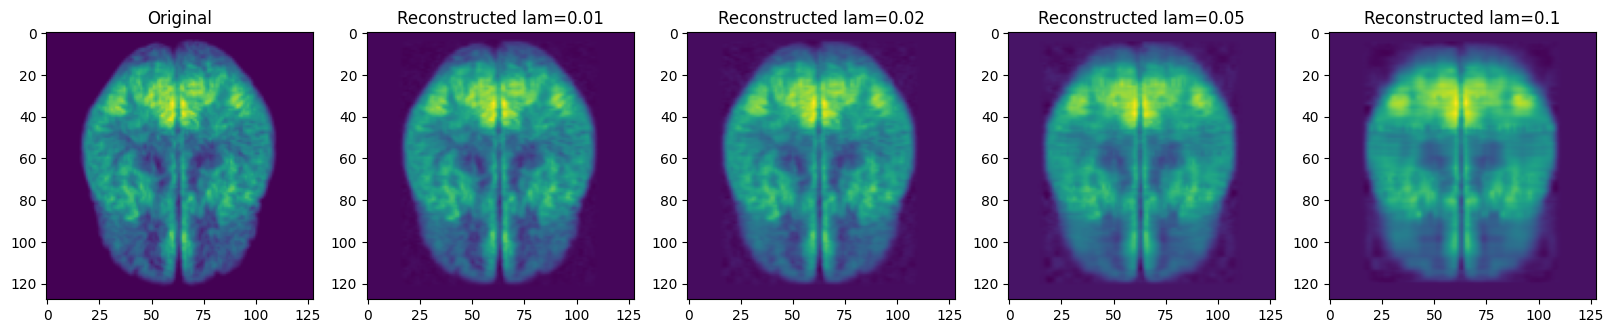

Image: mwc1MR_1021_2_20160916100329.nii

Lambda: 0.01
Number of Zeros X: 12399
Number of Zeros Y: 7017
Sparsity of X: 1.8802681402525872
Error of AX: 3.722253641866577e-05

Lambda: 0.02
Number of Zeros X: 13896
Number of Zeros Y: 7017
Sparsity of X: 1.7095449531818352
Error of AX: 6.339989013499542e-05

Lambda: 0.05
Number of Zeros X: 15381
Number of Zeros Y: 7017
Sparsity of X: 1.4918100575534496
Error of AX: 0.00011753168026342707

Lambda: 0.1
Number of Zeros X: 15869
Number of Zeros Y: 7017
Sparsity of X: 1.3437985387012512
Error of AX: 0.00018421624756651762


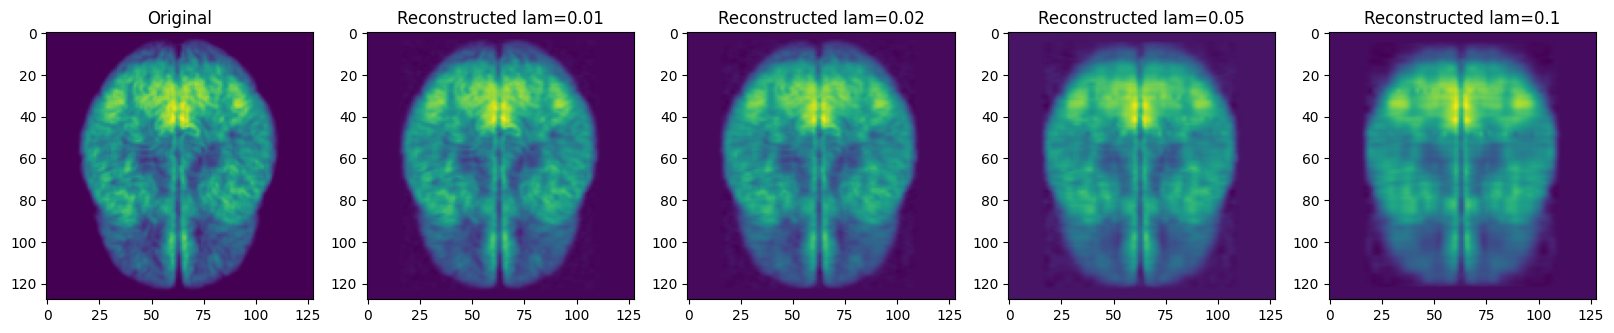

In [26]:
img_strs, zero_X_strs, zero_Y, zero_Y_strs, sparsity_strs, error_strs =\
    [], [], [], [], [], []
lam = [0.01, 0.02, 0.05, 0.10]

for i in range(10):
    img_str, zeros_X_list, zeros_Y, sparsity_list, error_list =\
        plot_mri(Y, [A_1, A_2, A_3, A_4], [X_1, X_2, X_3, X_4], lam, i)
    img_strs.extend([img_str] * 4)
    zero_X_strs.extend(zeros_X_list)
    zero_Y.extend([zeros_Y] * 4)
    zero_Y_strs.append(zeros_Y)
    sparsity_strs.extend(sparsity_list)
    error_strs.extend(error_list)

In [27]:
reconstructed_image_avg = pd.DataFrame(
    {
        "Lambda": lam,
        "Average Number of Zeros X": [
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(0, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(0, len(zero_X_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(1, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(1, len(zero_X_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(2, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(2, len(zero_X_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([zero_X_strs[i] for i in range(3, len(zero_X_strs), 4)])),
                    "+-",
                    str(np.std([zero_X_strs[i] for i in range(3, len(zero_X_strs), 4)]))
                ]
            )
        ],
        "Average Number of Zeros Y": [
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            ),
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            ),
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            ),
            " ".join(
                [
                    str(np.mean(zero_Y_strs)),
                    "+-",
                    str(np.std(zero_Y_strs))
                ]
            )
        ],
        "Average Sparsity": [
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(0, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(0, len(sparsity_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(1, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(1, len(sparsity_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(2, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(2, len(sparsity_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([sparsity_strs[i] for i in range(3, len(sparsity_strs), 4)])),
                    "+-",
                    str(np.std([sparsity_strs[i] for i in range(3, len(sparsity_strs), 4)]))
                ]
            )
        ],
        "Average Error": [
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(0, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(0, len(error_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(1, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(1, len(error_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(2, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(2, len(error_strs), 4)]))
                ]
            ),
            " ".join(
                [
                    str(np.mean([error_strs[i] for i in range(3, len(error_strs), 4)])),
                    "+-",
                    str(np.std([error_strs[i] for i in range(3, len(error_strs), 4)]))
                ]
            )
        ]
    }
)

reconstructed_image_avg.to_csv("Tables/reconstructed_image_avg.csv", index=None)
reconstructed_image_avg

,Lambda,Average Number of Zeros X,Average Number of Zeros Y,Average Sparsity,Average Error
0,0.01,12439.7 +- 145.9911298675368,7211.4 +- 102.99339784665811,1.894601686483544 +- 0.027459196771470816,3.6790731780914136e-05 +- 5.671174570436051e-07
1,0.02,13949.3 +- 100.23976256955122,7211.4 +- 102.99339784665811,1.7072135721048902 +- 0.026662923751627453,6.297150171361121e-05 +- 1.3794243120936363e-06
2,0.05,15417.1 +- 70.56550148620784,7211.4 +- 102.99339784665811,1.4831401103698871 +- 0.021935015075362472,0.00011524481854395309 +- 4.646537503290068e-06
3,0.10,15901.8 +- 28.833314065504158,7211.4 +- 102.99339784665811,1.3393393237869753 +- 0.017298045373130174,0.00017348722571560376 +- 9.858074238954136e-06


In [28]:
reconstructed_image_data = pd.DataFrame(
    {
        "Image": img_strs, "Number of Zeros X": zero_X_strs,
        "Number of Zeros Y": zero_Y, "Sparsity": sparsity_strs,
        "Error": error_strs, "Lambda": lam * 10
    }
)
reconstructed_image_data.to_csv('Tables/reconstructed_image_data.csv', index=None)